# Experimental ARPEGE forecasts

METEO FRANCE provides forecasts from a modified version of the ARPEGE global NWP model that allows supersaturation with respect to ice. This experimental model was developed in the frame of the [CICONIA](https://www.sesarju.eu/projects/CICONIA) SESAR EJU project and validated against [IAGOS](https://www.iagos.org/) observations (see [Arriolabengoa et al. 2025](https://doi.org/10.5194/acp-25-18051-2025)).

Global forecasts are initialized at 0z and 12z and provide hourly data out to 48 hours on pressure levels ranging from 1000hPa to 100hPa with an horizontal resolution of 0.25°. Data are freely distributed for research purposes only, through the CC [BY-NC-SA](https://creativecommons.org/licenses/by-nc-sa/4.0/) license. Credentials for ftp access will be given on e-mail request to req_cred.contrails_arpege-cnrm@meteo.fr. (Please describe your organization and related research activities in the email body.)

Due to its experimental status, the forecast FTP server is not monitored 24/7 and may experience interruptions or be suspended.

This notebook provides instructions for
1. accessing experimental ARPEGE forecasts through the METEO FRANCE FTP server, and
1. preprocessing experimental ARPEGE forecasts for use in pycontrails.

## Forecast access

The METEO FRANCE FTP server provides access to recent forecasts (typically those initialized within the last 48 hours) but does not provide a long-term forecast archive.

Contrails.org maintains a limited historical archive of experimental ARPEGE forecasts that can be shared with permission from METEO FRANCE. To request historical ARPEGE data from Contrails.org, email all@contrails.org and copy req_cred.contrails_arpege-cnrm@meteo.fr.

In [2]:
import os
from ftplib import FTP

In [10]:
ftp = FTP("ftp.umr-cnrm.fr")
ftp.login(os.environ["FTP_USER"], os.environ["FTP_PASSWORD"])
ftp.cwd("arpege/glob025")
ftp.nlst()

['20260720T0000P',
 '20260831T1200P',
 '20260901T0000P',
 '20260901T1200P',
 '20260902T0000P']

Data are provided in one GRIB file per forecast cycle. GRIB files contain one message per variable, per level, and per time step, and are about XX GB in size.

In [11]:
sink = "tmp.grib"
with open(sink, "wb") as f:
    ftp.retrbinary("RETR 20260901T1200P/grid.arpege-forecast.glob025.grib", f.write)

Pressure-level variables are provided with a variable vertical resolution (25 hPa from 100-300 hPa and 900-1000 hPa, and 50 hPa elsewhere) and hourly time steps from 1 to 48 hours. Nine parameters are available:

| Parameter | Description | Units | Notes |
| --- | --- | --- | --- |
| `u` | Zonal (eastward) wind | m s$^{-1}$ |
| `v` | Meridional (northward) wind | m s$^{-1}$ |
| `t` | Temperature | K |
| `ciwc` | Cloud ice water content | kg kg$^{-1}$ |
| `cc` | Cloud fraction | 1 |
| `z` | Geopotential | m$^2$ s$^{-2}$ |
| `r` | Relative humidity | % | with respect to ice |
| `pv` | Potential vorticity | K m$^2$ kg$^{-1}$ s$^{-1}$ |
| `w` | Vertical velocity | Pa s$^{-1}$ | pressure coordinates, positive downward |

Pressure-level variables can be read as an xarray Dataset by filtering by vertical coordinate:

In [13]:
import xarray as xr

In [75]:
pl = xr.open_dataset(
    sink,
    engine="cfgrib",
    chunks={"step": 1},
    backend_kwargs={"filter_by_keys": {"typeOfLevel": "isobaricInhPa"}},
)
pl

<xarray.Dataset> Size: 43GB
Dimensions:        (step: 48, isobaricInhPa: 24, latitude: 721, longitude: 1440)
Coordinates:
  * step           (step) timedelta64[ns] 384B 01:00:00 ... 2 days 00:00:00
    valid_time     (step) datetime64[ns] 384B dask.array<chunksize=(1,), meta=np.ndarray>
  * isobaricInhPa  (isobaricInhPa) float64 192B 1e+03 950.0 ... 125.0 100.0
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    time           datetime64[ns] 8B ...
Data variables:
    u              (step, isobaricInhPa, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    v              (step, isobaricInhPa, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    t              (step, isobaricInhPa, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    ciwc           (step, isobaricInhPa, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    cc             (step, isobaricInhPa, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    z              (step, isobaricInhPa, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    r              (step, isobaricInhPa, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    pv             (step, isobaricInhPa, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    w              (step, isobaricInhPa, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             lfpw
    GRIB_centreDescription:  French Weather Service - Toulouse
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             French Weather Service - Toulouse
    history:                 2026-09-02T13:18 GRIB to CDM+CF via cfgrib-0.9.1...

GRIB files also include three single-level variables:
| Parameter | Description | Units | Notes |
| --- | --- | --- | --- |
| `ssrd` | Surface downwelling shortwave flux | J m$^{-2}$ | Accumulated
| `tsr` | TOA net shortwave flux | J m$^{-2}$ | Positive downward, accumulated
| `ttr` | TOA net longwave flux | J m$^{-2}$ | Positive downward, accumulated

In [76]:
sl = xr.open_dataset(
    sink,
    engine="cfgrib",
    chunks={"step": 1},
    backend_kwargs={"filter_by_keys": {"typeOfLevel": ["nominalTop", "surface"]}},
)
sl

<xarray.Dataset> Size: 598MB
Dimensions:     (step: 48, latitude: 721, longitude: 1440)
Coordinates:
  * step        (step) timedelta64[ns] 384B 01:00:00 ... 2 days 00:00:00
    valid_time  (step) datetime64[ns] 384B dask.array<chunksize=(1,), meta=np.ndarray>
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time        datetime64[ns] 8B ...
    surface     float64 8B ...
    nominalTop  float64 8B ...
Data variables:
    ssrd        (step, latitude, longitude) float32 199MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    tsr         (step, latitude, longitude) float32 199MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    ttr         (step, latitude, longitude) float32 199MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             lfpw
    GRIB_centreDescription:  French Weather Service - Toulouse
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             French Weather Service - Toulouse
    history:                 2026-09-02T13:18 GRIB to CDM+CF via cfgrib-0.9.1...

## Preprocessing for use in pycontrails

Both pressure-level and single-level variables require preprocessing for use in pycontrails.

In [77]:
import numpy as np

from pycontrails.core.met_var import (
    AirTemperature,
    EastwardWind,
    MassFractionOfCloudIceInAir,
    NorthwardWind,
    SpecificHumidity,
    TOANetDownwardShortwaveFlux,
    TOAOutgoingLongwaveFlux,
    VerticalVelocity,
)
from pycontrails.physics import thermo

For pressure-level variables, specific humidity must be computed from relative humidity...

In [78]:
pl["q"] = 0.01 * pl["r"] * thermo.q_sat_ice(pl["t"], pl["isobaricInhPa"] * 100.0)

... `"step"` and `"isobaricInhPa"` coordinates must be replaced by `"time"` and `"level"` coordinates ...

In [79]:
pl = pl.assign_coords(step=pl["valid_time"])
pl = pl.drop_vars(["time", "valid_time"])
pl = pl.rename(step="time", isobaricInhPa="level")

... provenance attributes must be provided ...

In [80]:
pl.attrs.update({"provider": "Meteo-France", "dataset": "ARPEGE", "product": "forecast"})

.. and variable names and attributes must be updated to align with pycontrails conventions.

In [81]:
pl_vars = {
    "u": EastwardWind,
    "v": NorthwardWind,
    "w": VerticalVelocity,
    "t": AirTemperature,
    "q": SpecificHumidity,
    "ciwc": MassFractionOfCloudIceInAir,
}

pl = pl[pl_vars.keys()]
for k, v in pl_vars.items():
    pl[k].attrs.update(
        {"units": v.units, "long_name": v.long_name, "standard_name": v.standard_name}
    )
pl = pl.rename({k: v.standard_name for k, v in pl_vars.items()})

In [82]:
pl

<xarray.Dataset> Size: 33GB
Dimensions:                              (time: 48, level: 24, latitude: 721,
                                          longitude: 1440)
Coordinates:
  * time                                 (time) datetime64[ns] 384B 2026-09-0...
  * level                                (level) float64 192B 1e+03 ... 100.0
  * latitude                             (latitude) float64 6kB 90.0 ... -90.0
  * longitude                            (longitude) float64 12kB 0.0 ... 359.8
Data variables:
    eastward_wind                        (time, level, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    northward_wind                       (time, level, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    lagrangian_tendency_of_air_pressure  (time, level, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    air_temperature                      (time, level, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    specific_humidity                    (time, level, latitude, longitude) float64 10GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
    mass_fraction_of_cloud_ice_in_air    (time, level, latitude, longitude) float32 5GB dask.array<chunksize=(1, 24, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             lfpw
    GRIB_centreDescription:  French Weather Service - Toulouse
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             French Weather Service - Toulouse
    history:                 2026-09-02T13:18 GRIB to CDM+CF via cfgrib-0.9.1...
    provider:                Meteo-France
    dataset:                 ARPEGE
    product:                 forecast

For single-level variables, the `"step"` coordinate must be replaced by a `"time"` coordinate and a singleton `"level"` coordinate must be added...

In [83]:
sl = sl.squeeze().assign_coords(step=sl["valid_time"])
sl = sl.drop_vars(["valid_time", "surface", "nominalTop"])
sl = sl.rename(step="time", time="init")
sl = sl.expand_dims("level", axis=1).assign_coords(level=[-1.0])

... accumulated fluxes must be converted to time averages ...

In [84]:
# expand time coordinate to include zero accumulated fluxes at forecast initialization
expanded = np.insert(sl["time"].values, 0, sl["init"].values)
sl = sl.reindex(time=expanded, fill_value=0.0)

In [85]:
# conversion drops initial step and shifts remaining steps backward by 30 minutes
dt = sl["time"].diff("time")
dt_s = dt / np.timedelta64(1, "s")
sl = sl.diff("time")
sl["ttr"] = sl["ttr"] / dt_s
sl["tsr"] = sl["tsr"] / dt_s
sl = sl.assign_coords(time=sl["time"] - 0.5 * dt)

... the sign of the TOA net longwave flux must be reversed so that values are positive upward ...

In [86]:
sl["ttr"] = -sl["ttr"]

... provenance attributes must be provided ...

In [87]:
sl.attrs.update({"provider": "Meteo-France", "dataset": "ARPEGE", "product": "forecast"})

.. and variable names and attributes must be updated to align with pycontrails conventions.

In [88]:
sl_vars = {
    "ttr": TOAOutgoingLongwaveFlux,
    "tsr": TOANetDownwardShortwaveFlux,
}

sl = sl[sl_vars.keys()]
for k, v in sl_vars.items():
    sl[k].attrs.update(
        {"units": v.units, "long_name": v.long_name, "standard_name": v.standard_name}
    )
sl = sl.rename({k: v.standard_name for k, v in sl_vars.items()})

In [89]:
sl

<xarray.Dataset> Size: 797MB
Dimensions:                          (time: 48, level: 1, latitude: 721,
                                      longitude: 1440)
Coordinates:
  * time                             (time) datetime64[ns] 384B 2026-09-01T12...
  * level                            (level) float64 8B -1.0
  * latitude                         (latitude) float64 6kB 90.0 89.75 ... -90.0
  * longitude                        (longitude) float64 12kB 0.0 0.25 ... 359.8
    init                             datetime64[ns] 8B ...
Data variables:
    toa_outgoing_longwave_flux       (time, level, latitude, longitude) float64 399MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    toa_net_downward_shortwave_flux  (time, level, latitude, longitude) float64 399MB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             lfpw
    GRIB_centreDescription:  French Weather Service - Toulouse
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             French Weather Service - Toulouse
    history:                 2026-09-02T13:18 GRIB to CDM+CF via cfgrib-0.9.1...
    provider:                Meteo-France
    dataset:                 ARPEGE
    product:                 forecast

## Run gridded CoCiP

After preprocessing, ARPEGE forecasts can be wrapped in `MetDataset`s for use in CoCiP simulations. Note that this requires a relatively recent pycontrails version (0.54.6 or later) with support for generic (model-agnostic) meteorology.

In [113]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import colors

import pycontrails
from pycontrails.core import MetDataset
from pycontrails.models.cocipgrid import CocipGrid
from pycontrails.models.ps_model import PSGrid
from pycontrails.physics import units

In [92]:
assert pycontrails.__version__ >= "0.54.6"

In [101]:
met = MetDataset(pl).wrap_longitude()
rad = MetDataset(sl).wrap_longitude()

source = CocipGrid.create_source(
    time=pl["time"][0],
    level=units.ft_to_pl(35_000),
    latitude=np.arange(-90, 90.25, 0.25),
    lon_step=0.25,
)

Pycontrails will produce warnings if provenance attributes indicate that met data is from a source not supported by an official datalib. This is intended as a warning to users that they are responsible for ensuring met data is correctly formatted, and is safe to ignore for preprocessed ARPEGE data. The warning can be suppressed by running CoCiP inside a context manager:
```python
import warnings

with warnings.catch_warnings():
   warnings.filterwarnings("ignore", message="Unknown", category=UserWarning)
   cocip = CocipGrid(met, rad, ...)
   result = cocip.eval(source)
```

No humidity scaling is required when running CoCiP using experimental ARPEGE data, as the forecast produces realistic supersaturation without one.

In [102]:
cocip = CocipGrid(
    met,
    rad,
    humidity_scaling=None,
    aircraft_performance=PSGrid(),
    aircraft_type="B738",
    dt_integration="5min",
    azimuth=None,
    segment_length=None,
    dsn_dz_factor=0.665,
    show_progress=False,
)

/Users/tristanabbott/Files/Code/contrails/pycontrails/pycontrails/core/met.py:1134: UserWarning: Unknown provider 'Meteo-France'. Data may not be processed correctly. Known providers are ('ECMWF', 'NCEP', 'DWD'). Contact the pycontrails developers if you believe this is an error.
  warnings.warn(
/Users/tristanabbott/Files/Code/contrails/pycontrails/pycontrails/core/met.py:1134: UserWarning: Unknown provider 'Meteo-France'. Data may not be processed correctly. Known providers are ('ECMWF', 'NCEP', 'DWD'). Contact the pycontrails developers if you believe this is an error.
  warnings.warn(


In [103]:
result = cocip.eval(source)

/Users/tristanabbott/Files/Code/contrails/pycontrails/pycontrails/core/met.py:1134: UserWarning: Unknown provider 'Meteo-France'. Data may not be processed correctly. Known providers are ('ECMWF', 'NCEP', 'DWD'). Contact the pycontrails developers if you believe this is an error.
  warnings.warn(
/Users/tristanabbott/Files/Code/contrails/pycontrails/pycontrails/core/met.py:1134: UserWarning: Unknown dataset 'ARPEGE'. Data may not be processed correctly. Known datasets are ('ERA5', 'HRES', 'IFS', 'GFS', 'ICON', 'ICON-EU', 'ICON-D2'). Contact the pycontrails developers if you believe this is an error.
  warnings.warn(


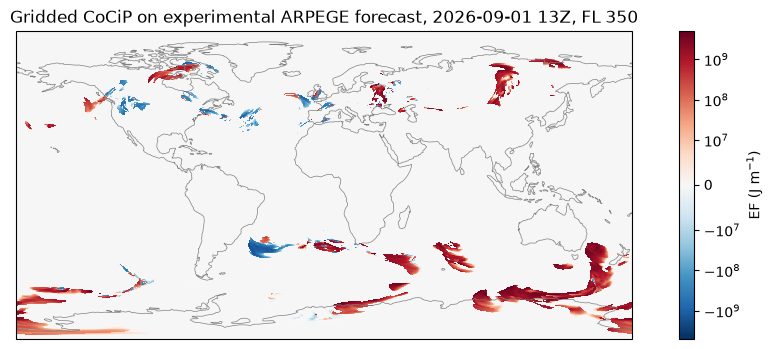

In [117]:
plt.figure(figsize=(12, 4))
ax = plt.subplot(111, projection=ccrs.PlateCarree())
im = ax.pcolormesh(
    result["longitude"].values,
    result["latitude"].values,
    result["ef_per_m"].values.squeeze().T,
    shading="nearest",
    cmap="RdBu_r",
    norm=colors.SymLogNorm(vmin=-5e9, vmax=5e9, linthresh=1e7),
)
ax.coastlines(color="gray", lw=0.5)

plt.colorbar(im, ax=ax, label="EF (J m$^{-1}$)")
t = pd.Timestamp(result["time"].data.item()).strftime("%Y-%m-%d %HZ")
plt.title(f"Gridded CoCiP on experimental ARPEGE forecast, {t}, FL 350");